<a href="https://colab.research.google.com/github/cocyten27/MODULE_6/blob/main/M6_L05_controlnet_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TAE-IA · Module 6 · L05 — ControlNet: Structure-Guided Generation

| | |
|---|---|
| **Module** | 6 — Practical AI Applications: Images and Audio |
| **Lesson** | L05 |
| **Track** | A — Vision |
| **Estimated duration** | 2 hours |
| **GPU required** | T4 (Colab) |
| **Prerequisites** | L01–L04 completed; L04 cleanup cell run |

## Learning objectives
By the end of this notebook you will be able to:
- [ ] Explain how ControlNet injects conditioning signals into the UNet without modifying its frozen weights
- [ ] Extract Canny edges and depth maps as conditioning inputs
- [ ] Use `StableDiffusionControlNetPipeline` with Canny and depth conditioners
- [ ] Tune `controlnet_conditioning_scale` and explain its effect

## Before you start
- L04 cleanup cell must have been run — frees Drive space for this lab's models
- T4 GPU runtime selected (`Runtime > Change runtime type > T4 GPU`)

---

## Cell 0 — Setup (always run this first)

> Mounts Drive, checks GPU, fixes seed, and logs in to HuggingFace.

In [ ]:
# ================================================================
# TAE-IA M6 · Standard Setup -- DO NOT MODIFY THIS CELL
# ================================================================
import os, sys, random, shutil
import numpy as np

from google.colab import drive
drive.mount('/content/drive')

MODEL_CACHE = '/content/drive/MyDrive/TAE_IA_M6/models'
os.makedirs(MODEL_CACHE, exist_ok=True)
print(f'Model cache: {MODEL_CACHE}')

# Clear any cache left by earlier course versions.
for _leftover in ('hub', 'xet'):
    _p = os.path.join(MODEL_CACHE, _leftover)
    if os.path.exists(_p):
        shutil.rmtree(_p)

import torch
if not torch.cuda.is_available():
    print('\nNo GPU detected. Go to: Runtime > Change runtime type > T4 GPU')
    raise SystemExit('GPU required.')

gpu_name = torch.cuda.get_device_name(0)
vram_gb  = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f'GPU: {gpu_name}  |  VRAM: {vram_gb:.1f} GB')

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
print(f'Fixed seed: {SEED}')
print(f'Python {sys.version.split()[0]}  |  PyTorch {torch.__version__}')

# HuggingFace login -- needed every new Colab session
import huggingface_hub

try:
    _token = huggingface_hub.get_token()
except Exception:
    _token = None

if _token:
    print(f"Already logged in to HuggingFace as: {huggingface_hub.whoami()['name']}")
else:
    try:
        from google.colab import userdata
        _hf_token = userdata.get('HF_TOKEN')
    except Exception:
        _hf_token = None

    if _hf_token:
        huggingface_hub.login(token=_hf_token, add_to_git_credential=False)
        print(f"Logged in to HuggingFace as: {huggingface_hub.whoami()['name']}")
    else:
        raise RuntimeError(
            'No HF_TOKEN found in Colab Secrets (key icon, left sidebar).\n'
            'Add a secret named HF_TOKEN with your HuggingFace read token, enable notebook access, '
            'then re-run this cell.\n'
            'See L00 Cell 4 if you need to generate a token or accept the SD 1.5 license.'
        )

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model cache: /content/drive/MyDrive/TAE_IA_M6/models
GPU: Tesla T4  |  VRAM: 15.6 GB
Fixed seed: 42
Python 3.13.15  |  PyTorch 2.11.0+cu128
Logged in to HuggingFace as: ingpereida


In [ ]:
# ================================================================
# Install dependencies for L05
# controlnet-aux provides preprocessing detectors (Canny, MiDaS, etc.)
# ================================================================
!pip install diffusers transformers accelerate controlnet-aux opencv-python-headless -q

import diffusers, controlnet_aux, cv2
print(f'diffusers {diffusers.__version__}  |  controlnet-aux {controlnet_aux.__version__}  |  OpenCV {cv2.__version__}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 290.4/290.4 kB 20.1 MB/s eta 0:00:00


/usr/local/lib/python3.13/dist-packages/controlnet_aux/mediapipe_face/mediapipe_face_common.py:7: UserWarning: The module 'mediapipe' is not installed. The package will have limited functionality. Please install it using the command: pip install 'mediapipe'
  warnings.warn(


diffusers 0.40.0  |  controlnet-aux 0.0.10  |  OpenCV 5.0.0


/usr/local/lib/python3.13/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/usr/local/lib/python3.13/dist-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/usr/local/lib/python3.13/dist-packages/controlnet_aux/segment_anything/modeling/tiny_vit_sam.py:654: UserWarning: Overwriting tiny_vit_5m_224 in registry with controlnet_aux.segment_anything.modeling.tiny_vit_sam.tiny_vit_5m_224. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  return register_model(fn_wrapper)
/usr/local/lib/python3.13/dist-packages/controlnet_aux/segment_anything/mode

---
## Part 1 — Context and Key Concepts

> Read this before running any code.

### The problem text prompts cannot solve

Text prompts excel at controlling *what* is in the image and *how it looks* (style, color, mood). They are poor at controlling *where* things are, *how* the camera is positioned, or *what pose* a subject holds. Running the same composition-specific prompt ten times produces ten different layouts.

img2img partially solves this by starting from an existing image, but it requires a near-finished source — a rough sketch or wireframe gives poor results because img2img encodes the *pixels*, not the *structure*.

### ControlNet architecture

ControlNet (Zhang et al., 2023) adds a **trainable copy of the UNet encoder** alongside the frozen SD 1.5 model:

```
Conditioning image (Canny / depth)
    │
    ▼
ControlNet Encoder  ← trainable, initialized from UNet encoder weights
    │  outputs feature maps at each resolution scale
    ▼  added to UNet skip connections and mid block
UNet (frozen SD 1.5)
    │
    ▼
VAE Decoder → output image
```

Because the SD 1.5 weights are frozen, **all of its generation quality is preserved**. ControlNet only adds structural guidance on top.

### `controlnet_conditioning_scale`

This parameter (default `1.0`) controls how strongly the ControlNet signal influences the output:
- `0.5`: soft guidance — model has more creative freedom, structure loosely followed
- `1.0`: balanced — good default for most use cases
- `1.5+`: strict guidance — model rigidly follows the control signal, may reduce image quality

### Canny vs. Depth conditioning

- **Canny edges:** captures object outlines and internal structure. Best when the source has clear, meaningful edges (architecture, mechanical objects, illustrations). Over-sensitive to noise.
- **Depth map:** captures near/far relationships. More robust to texture and noise than Canny. Best for controlling perspective and 3D layout without locking in specific shapes.

Each conditioner requires its own ControlNet checkpoint — they are not interchangeable.

---

## Part 2 — Lab

### Section 2.0 — Load pipeline

Loads SD 1.5 once. Every ControlNet pipeline built later in this lab reuses these same loaded
components instead of reloading the base model from scratch — the original version of this
notebook reloaded SD 1.5 from scratch four separate times.

In [ ]:
# Section 2.0 — Load pipeline
from diffusers import StableDiffusionPipeline
from huggingface_hub import snapshot_download
import torch, gc, os, cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

def gen(seed=SEED):
    return torch.Generator("cuda").manual_seed(seed)

OUTPUT_DIR = '/content/drive/MyDrive/TAE_IA_M6/L05_output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Fetch only the fp16 weights + configs (~2.5 GB) -- shared with L01-L04 if already cached.
SD15_DIR = os.path.join(MODEL_CACHE, 'sd15-local')
snapshot_download(
    "runwayml/stable-diffusion-v1-5",
    local_dir=SD15_DIR,
    allow_patterns=["*.json", "*.txt", "*.fp16.safetensors"],
)

# Loaded once, kept alive for the whole notebook -- every ControlNet pipeline below reuses
# these components instead of reloading SD 1.5 from scratch.
pipe_txt = StableDiffusionPipeline.from_pretrained(
    SD15_DIR,
    torch_dtype=torch.float16,
    variant="fp16",
).to("cuda")
print("txt2img pipeline loaded (stays loaded for the rest of this notebook).")

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:07<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

txt2img pipeline loaded (stays loaded for the rest of this notebook).


### Section 2.1 — Generate source image and extract Canny edges

  0%|          | 0/25 [00:00<?, ?it/s]

Source generated.
Canny edges extracted.


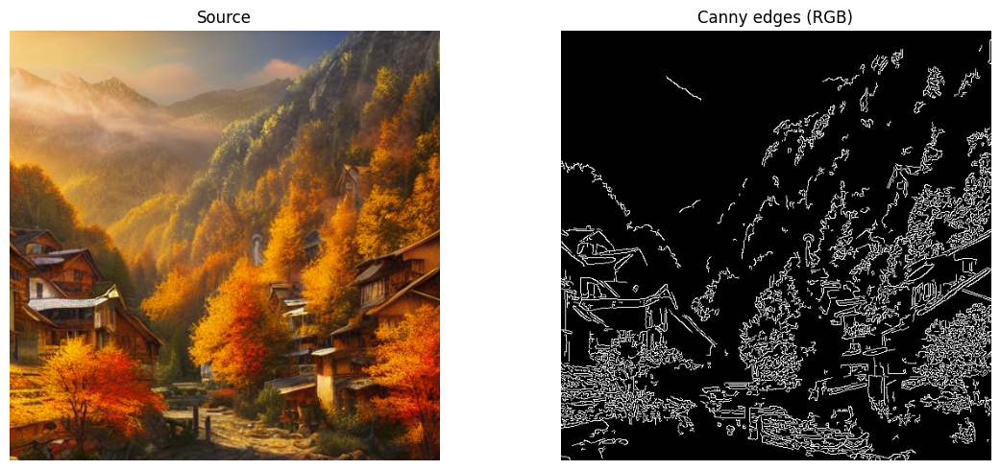

In [ ]:
# Section 2.1 — Source image and Canny preprocessing
SOURCE_PROMPT = "a mountain village in autumn, warm golden light, photorealistic, high detail"
source = pipe_txt(
    SOURCE_PROMPT,
    num_inference_steps=25, guidance_scale=7.5, generator=gen()
).images[0]
source = source.resize((512, 512))
source.save(os.path.join(OUTPUT_DIR, "source.png"))
print("Source generated.")

# Extract Canny edges
gray         = np.array(source.convert("L"))
edges        = cv2.Canny(gray, threshold1=100, threshold2=200)
canny_image  = Image.fromarray(edges).convert("RGB")   # ControlNet expects RGB
canny_image.save(os.path.join(OUTPUT_DIR, "canny.png"))
print("Canny edges extracted.")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(source); axes[0].set_title("Source"); axes[0].axis('off')
axes[1].imshow(canny_image); axes[1].set_title("Canny edges (RGB)"); axes[1].axis('off')
plt.tight_layout(); plt.show()

**What do you observe?**  
- Which parts of the image produced the most edges? Which areas are sparse?
- Are there any edges that look like noise rather than real structure?

Las areas como con contornos mas definidos fueron las que presentaron  mayor cantidad de bordes, tambien se nota las que estan como en color mas obscuro se definieron los bordes mas, y las areas abiertas o con mayor luminocidad los bordes no los marcaba tanto, por ejemplo en el cielo y las montañas que se ven mas alejadas.

No se observa como tal que alguno de los bordes sea o se genere como ruido, pero si pudera serlo en algunas partes o áreas.

### Section 2.2 — Canny ControlNet: style variations preserving composition

Load the Canny ControlNet checkpoint and generate several styles from the same edge map.

In [ ]:
# Section 2.2 — Load ControlNet-Canny pipeline
from diffusers import ControlNetModel, StableDiffusionControlNetPipeline
from diffusers import UniPCMultistepScheduler

# This checkpoint doesn't ship an fp16-suffixed variant, only fp32 -- torch_dtype still
# casts it to fp16 in memory. Configs + the one weight format, skip the .bin duplicate.
CANNY_DIR = os.path.join(MODEL_CACHE, 'controlnet-canny-local')
snapshot_download(
    "lllyasviel/sd-controlnet-canny",
    local_dir=CANNY_DIR,
    allow_patterns=["*.json", "*.safetensors"],
)
controlnet_canny = ControlNetModel.from_pretrained(CANNY_DIR, torch_dtype=torch.float16)

# Reuses pipe_txt's already-loaded components -- no second SD 1.5 load from disk.
pipe_canny = StableDiffusionControlNetPipeline(controlnet=controlnet_canny, **pipe_txt.components).to("cuda")
# UniPC needs fewer steps than PNDM — 20 is enough
pipe_canny.scheduler = UniPCMultistepScheduler.from_config(pipe_canny.scheduler.config)
print("ControlNet-Canny pipeline ready.")

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

ControlNet-Canny pipeline ready.


  0%|          | 0/20 [00:00<?, ?it/s]

Done: oil painting, impressionist, warm autumn


  0%|          | 0/20 [00:00<?, ?it/s]

Done: watercolor illustration, soft pastels, s


  0%|          | 0/20 [00:00<?, ?it/s]

Done: cyberpunk neon city, rain reflections, n


  0%|          | 0/20 [00:00<?, ?it/s]

Done: pencil sketch, detailed linework, black 


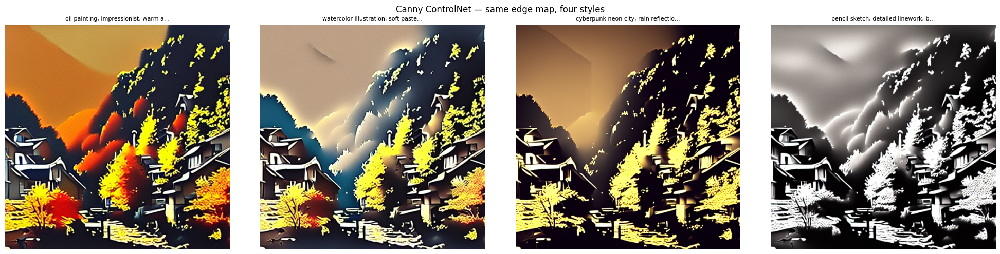

In [ ]:
# Section 2.2 — Style variations from the same Canny map
style_prompts = [
    "oil painting, impressionist, warm autumn colors, Van Gogh style",
    "watercolor illustration, soft pastels, storybook art",
    "cyberpunk neon city, rain reflections, night scene",
    "pencil sketch, detailed linework, black and white",
]

canny_results = []
for prompt in style_prompts:
    img = pipe_canny(
        prompt                        = prompt,
        image                         = canny_image,
        controlnet_conditioning_scale = 1.0,
        num_inference_steps           = 20,
        guidance_scale                = 7.5,
        generator                     = gen()
    ).images[0]
    fname = prompt[:30].replace(",", "").replace(" ", "_") + ".png"
    img.save(os.path.join(OUTPUT_DIR, f"canny_{fname}"))
    canny_results.append((prompt[:35] + "...", img))
    print(f"Done: {prompt[:40]}")

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, (label, img) in zip(axes, canny_results):
    ax.imshow(img); ax.set_title(label, fontsize=8, wrap=True); ax.axis('off')
plt.suptitle("Canny ControlNet — same edge map, four styles", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "canny_style_grid.png"), dpi=100)
plt.show()

**What do you observe?**  
- Which structural elements (rooflines, mountain shapes, paths) appear consistently across all four styles?
- Which style diverged most from the source composition? Why do you think?
- Does the cyberpunk prompt make spatial sense given the village edge map?

*Write your observation here:*

algunas estructuras como las casas, techos, la montaña que esta mas cercana a la vista prevalecen en las pinturas. ventanas y los arboles que estan mas hacia el frente de las pinturas tambien son los que prevalecen.

desde mi punto de vista la imagen 4 la que esta a lapiz fue la que se alejó un poco mas de la imagen original, y tal vez sea por el tipo de composicion, que es mas como dibujo a lapiz, sin tanto detalle.

y la imagen Cyberpunk no se aleja tanto de la imagen original, si exagera en algunas cosas y omite algunas otras que estan mas alejadas en la imagen pero trata de ser apegada a la original.

### Section 2.3 — Conditioning scale experiment

Run the same Canny image and prompt at three different `controlnet_conditioning_scale` values.

  0%|          | 0/20 [00:00<?, ?it/s]

conditioning_scale=0.5 done


  0%|          | 0/20 [00:00<?, ?it/s]

conditioning_scale=1.0 done


  0%|          | 0/20 [00:00<?, ?it/s]

conditioning_scale=1.5 done


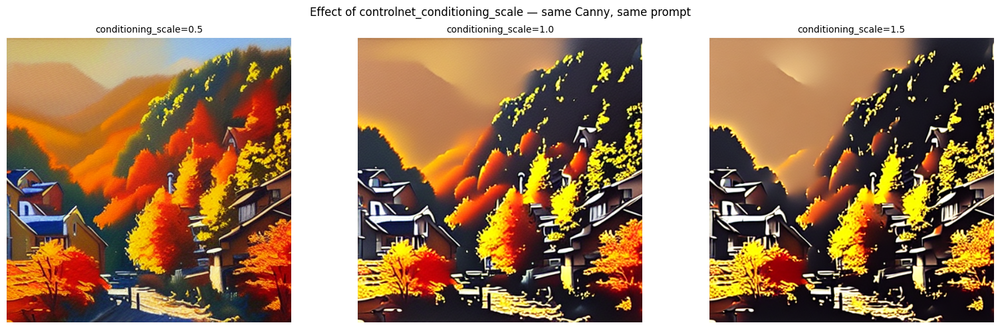

In [ ]:
# Section 2.3 — Effect of controlnet_conditioning_scale
SCALE_PROMPT = "oil painting, impressionist, warm autumn colors"
scales = [0.5, 1.0, 1.5]

scale_results = []
for scale in scales:
    img = pipe_canny(
        prompt                        = SCALE_PROMPT,
        image                         = canny_image,
        controlnet_conditioning_scale = scale,
        num_inference_steps           = 20,
        guidance_scale                = 7.5,
        generator                     = gen()
    ).images[0]
    img.save(os.path.join(OUTPUT_DIR, f"scale_{str(scale).replace('.','')}.png"))
    scale_results.append((scale, img))
    print(f"conditioning_scale={scale} done")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (scale, img) in zip(axes, scale_results):
    ax.imshow(img); ax.set_title(f"conditioning_scale={scale}", fontsize=10); ax.axis('off')
plt.suptitle("Effect of controlnet_conditioning_scale — same Canny, same prompt", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "scale_comparison.png"), dpi=100)
plt.show()

**What do you observe?**  
- At `0.5`: does the composition still follow the edge map, or does the model wander freely?
- At `1.5`: does over-conditioning produce any visible quality degradation?
- Which scale would you use for artistic stylization vs. strict technical reproduction?

Write your observation here:

* En 0.5 aun Hay cierto respeto a los bordes
* En 1.5 si se ve una degradacion visible y una calidad como mas un negativo de fotrografia que la fotografia en si.



- **¿Qué escala usaría?**
    - Para **estilización artística**: Utilizaría una escala más baja, como **0.5 o incluso menos**, para darle al modelo más libertad creativa y permitirle interpretar el estilo del prompt de manera más flexible sin estar excesivamente atado a la estructura original.
    - Para **reproducción técnica estricta**: Utilizaría una escala más alta, como **1.0 o 1.5**, para asegurar que la estructura y los detalles del mapa de bordes se mantengan lo más fielmente posible, aunque esto pueda comprometer un poco la calidad artística general de la imagen en casos de sobre-condicionamiento.

### Section 2.4 — Depth map conditioning with MiDaS

Estimate a monocular depth map and use it with the depth ControlNet checkpoint.

VRAM freed: 12.1 GB available


dpt_hybrid-midas-501f0c75.pt: reconstructing file:   0%|          |  0.00B /  493MB            

dpt_hybrid-midas-501f0c75.pt: downloading bytes:           |  0.00B            

/usr/local/lib/python3.13/dist-packages/timm/models/_factory.py:175: UserWarning: Mapping deprecated model name vit_base_resnet50_384 to current vit_base_r50_s16_384.orig_in21k_ft_in1k.
  model = create_fn(


Depth map estimated.


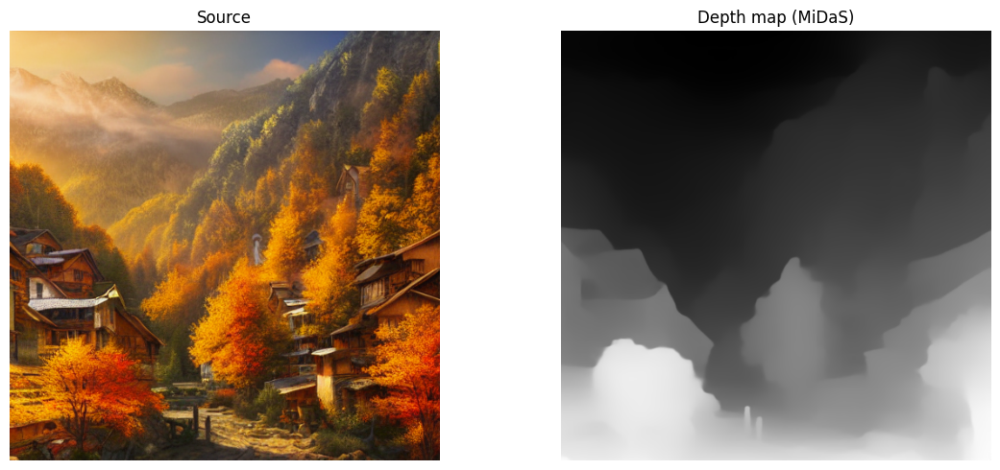

In [ ]:
# Section 2.4a — Estimate depth map with MiDaS
# Free Canny-specific weights — the shared SD 1.5 base (referenced by pipe_txt) stays loaded.
del pipe_canny, controlnet_canny; gc.collect(); torch.cuda.empty_cache()
print(f"VRAM freed: {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated(0))/1e9:.1f} GB available")

from controlnet_aux import MidasDetector

# lllyasviel/Annotators is a 12.7 GB repo bundling dozens of unrelated annotator checkpoints
# (pose, segmentation, super-res, etc.) -- MidasDetector.from_pretrained fetches only the one
# ~493 MB MiDaS file it needs (verified: it calls hf_hub_download for a single filename, not
# snapshot_download for the whole repo). Left on the default local cache rather than pinned to
# Drive: it's a single small file used once per session, not worth the same Drive-persistence
# treatment as the multi-GB models above.
midas     = MidasDetector.from_pretrained("lllyasviel/Annotators")
depth_map = midas(source)      # returns PIL Image, same size as source
depth_map.save(os.path.join(OUTPUT_DIR, "depth.png"))
print("Depth map estimated.")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(source); axes[0].set_title("Source"); axes[0].axis('off')
axes[1].imshow(depth_map); axes[1].set_title("Depth map (MiDaS)"); axes[1].axis('off')
plt.tight_layout(); plt.show()

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

ControlNet-Depth pipeline ready.


  0%|          | 0/20 [00:00<?, ?it/s]

Depth ControlNet done.


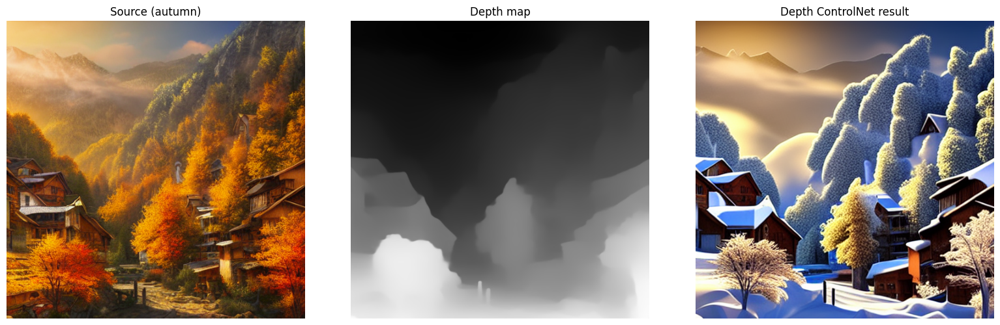

In [ ]:
# Section 2.4b — Load depth ControlNet and generate
DEPTH_DIR = os.path.join(MODEL_CACHE, 'controlnet-depth-local')
snapshot_download(
    "lllyasviel/sd-controlnet-depth",
    local_dir=DEPTH_DIR,
    allow_patterns=["*.json", "*.safetensors"],
)
controlnet_depth = ControlNetModel.from_pretrained(DEPTH_DIR, torch_dtype=torch.float16)

# Reuses pipe_txt's already-loaded components -- no second SD 1.5 load from disk.
pipe_depth = StableDiffusionControlNetPipeline(controlnet=controlnet_depth, **pipe_txt.components).to("cuda")
pipe_depth.scheduler = UniPCMultistepScheduler.from_config(pipe_depth.scheduler.config)
print("ControlNet-Depth pipeline ready.")

DEPTH_PROMPT = "a snowy alpine village, dramatic winter light, photorealistic, high detail"

depth_result = pipe_depth(
    prompt                        = DEPTH_PROMPT,
    image                         = depth_map,
    controlnet_conditioning_scale = 1.0,
    num_inference_steps           = 20,
    guidance_scale                = 7.5,
    generator                     = gen()
).images[0]
depth_result.save(os.path.join(OUTPUT_DIR, "depth_result.png"))
print("Depth ControlNet done.")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(source); axes[0].set_title("Source (autumn)"); axes[0].axis('off')
axes[1].imshow(depth_map); axes[1].set_title("Depth map"); axes[1].axis('off')
axes[2].imshow(depth_result); axes[2].set_title("Depth ControlNet result"); axes[2].axis('off')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "depth_pipeline.png"), dpi=100)
plt.show()

**What do you observe?**  
- Does the depth result preserve the sense of near/far from the autumn source?
- Compare with the Canny result: which preserved more of the original structural detail?

Aquí están mis observaciones:

- **¿El resultado de profundidad conserva el sentido de cerca/lejos de la fuente de otoño?**
    Sí, el resultado generado con ControlNet de profundidad conserva muy bien el sentido de cerca/lejos de la imagen original de otoño. Las casas en primer plano siguen estando en primer plano y las montañas en el fondo se mantienen en el fondo, lo que demuestra que el mapa de profundidad capturó eficazmente las relaciones espaciales y el modelo las tradujo a la nueva imagen de pueblo alpino nevado.

- **Comparado con el resultado de Canny: ¿cuál conservó más el detalle estructural original?**
    Comparado con los resultados de Canny, el ControlNet de **Canny conservó más del detalle estructural original** en términos de contornos precisos. Canny se enfoca en las líneas y los bordes, reproduciendo con alta fidelidad las siluetas de los tejados, las ramas de los árboles y las formas de las casas. El ControlNet de profundidad, aunque excelente para mantener la composición general y la perspectiva 3D, tiende a ser menos específico con los detalles finos de la estructura, pudiendo interpretar de forma más libre los elementos dentro de las grandes masas y distancias.

### Section 2.5 — Three-way comparison: txt2img vs. Canny vs. Depth

Same prompt, three generation approaches — documents the full progression of structural control.

  0%|          | 0/25 [00:00<?, ?it/s]

txt2img done.


  0%|          | 0/20 [00:00<?, ?it/s]

Canny ControlNet done.


  0%|          | 0/20 [00:00<?, ?it/s]

Depth ControlNet done.


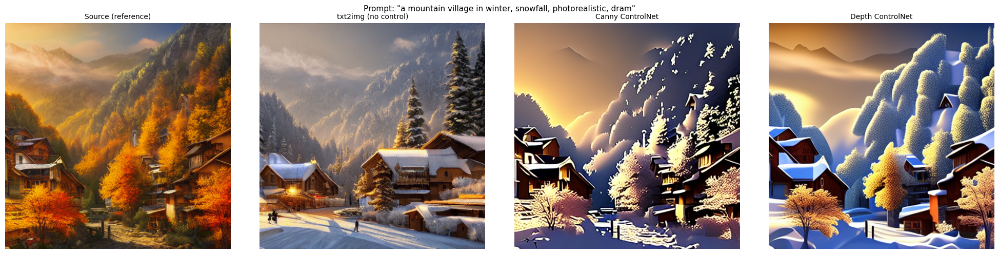

In [ ]:
# Section 2.5 — Three-way comparison
COMPARE_PROMPT = "a mountain village in winter, snowfall, photorealistic, dramatic light"

# 1. txt2img — no structural control. pipe_txt has been loaded since Section 2.0; no reload.
img_txt = pipe_txt(
    COMPARE_PROMPT, num_inference_steps=25, guidance_scale=7.5, generator=gen()
).images[0]
img_txt.save(os.path.join(OUTPUT_DIR, "compare_txt2img.png"))
print("txt2img done.")

# 2. ControlNet + Canny — weights already cached locally from Section 2.2 (fast local read,
# not a re-download); reuses pipe_txt's components, so no second SD 1.5 load either.
controlnet_canny = ControlNetModel.from_pretrained(CANNY_DIR, torch_dtype=torch.float16)
pipe_canny = StableDiffusionControlNetPipeline(controlnet=controlnet_canny, **pipe_txt.components).to("cuda")
pipe_canny.scheduler = UniPCMultistepScheduler.from_config(pipe_canny.scheduler.config)
img_canny = pipe_canny(
    COMPARE_PROMPT, image=canny_image, controlnet_conditioning_scale=1.0,
    num_inference_steps=20, guidance_scale=7.5, generator=gen()
).images[0]
img_canny.save(os.path.join(OUTPUT_DIR, "compare_canny.png"))
del pipe_canny, controlnet_canny; gc.collect(); torch.cuda.empty_cache()
print("Canny ControlNet done.")

# 3. ControlNet + Depth — same pattern.
controlnet_depth = ControlNetModel.from_pretrained(DEPTH_DIR, torch_dtype=torch.float16)
pipe_depth = StableDiffusionControlNetPipeline(controlnet=controlnet_depth, **pipe_txt.components).to("cuda")
pipe_depth.scheduler = UniPCMultistepScheduler.from_config(pipe_depth.scheduler.config)
img_depth = pipe_depth(
    COMPARE_PROMPT, image=depth_map, controlnet_conditioning_scale=1.0,
    num_inference_steps=20, guidance_scale=7.5, generator=gen()
).images[0]
img_depth.save(os.path.join(OUTPUT_DIR, "compare_depth.png"))
del pipe_depth, controlnet_depth; gc.collect(); torch.cuda.empty_cache()
print("Depth ControlNet done.")

# Display
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, (title, img) in zip(axes, [
    ("Source (reference)", source),
    ("txt2img (no control)", img_txt),
    ("Canny ControlNet", img_canny),
    ("Depth ControlNet", img_depth),
]):
    ax.imshow(img); ax.set_title(title, fontsize=10); ax.axis('off')
plt.suptitle(f'Prompt: "{COMPARE_PROMPT[:60]}"', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "three_way_comparison.png"), dpi=100)
plt.show()

**What do you observe?**  
- Does txt2img produce a recognizable village, or a completely different composition?
- Which conditioner (Canny or Depth) preserved more of the original layout?
- Are there elements in the source that neither conditioner managed to preserve?

observaciones:

- **¿`txt2img` produce un pueblo reconocible, o una composición completamente diferente?**
    El `txt2img` (sin control estructural) produce una composición completamente diferente. Aunque el prompt "a mountain village in winter, snowfall, photorealistic, dramatic light" es el mismo, el resultado muestra un paisaje invernal con nieve y montañas, pero la disposición de las casas, los árboles y el camino es distinta a la de la imagen original. No es el *mismo* pueblo, sino *un* pueblo de montaña genérico en invierno.

- **¿Qué condicionador (Canny o Profundidad) conservó más el diseño original?**
    Ambos condicionadores, Canny y Profundidad, conservaron significativamente más del diseño original que `txt2img`. Sin embargo, el ControlNet de **Canny conservó el diseño original de manera más detallada y precisa** en cuanto a la forma y ubicación de cada elemento (tejados, contornos de las casas, árboles). El ControlNet de Profundidad mantuvo la estructura espacial y las relaciones de cerca/lejos, pero la interpretación de las formas específicas de los edificios y el follaje fue más libre.

- **¿Hay elementos en la fuente que ninguno de los condicionadores logró preservar?**
    Sí, hay elementos sutiles o detalles finos en la imagen fuente que ninguno de los condicionadores logró preservar perfectamente. Por ejemplo, la **textura específica de la vegetación** o las **pequeñas irregularidades en las paredes de las casas**. Si bien ambos ControlNet replican la forma general de los árboles y edificios, los detalles microscópicos y las texturas orgánicas del original a menudo se reinventan o se suavizan en las imágenes generadas.

---
## Part 3 — Exercises

### Exercise 1 — Your own subject with Canny

**Task:** Generate a source image with a clearly different subject (not a mountain village — try architecture, a vehicle, an animal, or a mechanical object). Extract Canny edges and generate at least 3 style variations. Show source → edges → all variations in a grid.

**Expected output:** Grid with labeled panels. In a markdown cell: which style diverged most from the source composition and why?

VRAM disponible después de liberar: 12.9 GB


/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

...

Variación de estilo 2 generada: a vintage car as a watercolor painting, ...


  0%|          | 0/20 [00:00<?, ?it/s]

Variación de estilo 3 generada: a vintage car as a blueprint drawing, de...


  0%|          | 0/20 [00:00<?, ?it/s]

Variación de estilo 4 generada: a vintage car made of rusty metal, post-...


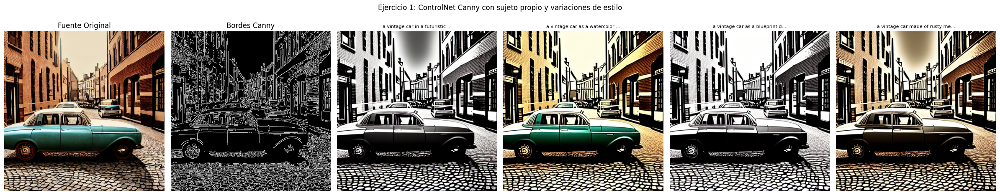

VRAM liberada después del Ejercicio 1: 10.1 GB disponible


In [ ]:
# Exercise 1 -- Canny ControlNet with your own subject
# Remember: save any images to OUTPUT_DIR, e.g. img.save(os.path.join(OUTPUT_DIR, "exercise1.png"))
# ...
import os
from PIL import Image
import numpy as np
import cv2
import matplotlib.pyplot as plt
from diffusers import ControlNetModel, StableDiffusionControlNetPipeline, UniPCMultistepScheduler
from huggingface_hub import snapshot_download
import torch, gc

# Liberar la memoria de la GPU de cualquier pipeline anterior para asegurar suficiente VRAM
del pipe_txt; gc.collect(); torch.cuda.empty_cache()
print(f"VRAM disponible después de liberar: {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated(0))/1e9:.1f} GB")

# Recargar el pipeline txt2img base para generar la nueva imagen fuente
# Se usa pipe_txt.components que fue guardado en el setup inicial
pipe_txt = StableDiffusionPipeline.from_pretrained(
    SD15_DIR,
    torch_dtype=torch.float16,
    variant="fp16",
).to("cuda")

# --- 1. Generar una nueva imagen fuente con un tema diferente ---
EX1_SOURCE_PROMPT = "a detailed vintage car, parked on a cobblestone street, sunlight, photorealistic"
source_ex1 = pipe_txt(
    EX1_SOURCE_PROMPT,
    num_inference_steps=25, guidance_scale=7.5, generator=gen()
).images[0]
source_ex1 = source_ex1.resize((512, 512))
source_ex1_path = os.path.join(OUTPUT_DIR, "exercise1_source.png")
source_ex1.save(source_ex1_path)
print(f"Nueva imagen fuente generada y guardada en {source_ex1_path}")

# --- 2. Extraer bordes Canny de la nueva imagen fuente ---
gray_ex1        = np.array(source_ex1.convert("L"))
edges_ex1       = cv2.Canny(gray_ex1, threshold1=100, threshold2=200)
canny_image_ex1 = Image.fromarray(edges_ex1).convert("RGB") # ControlNet espera RGB
canny_image_ex1_path = os.path.join(OUTPUT_DIR, "exercise1_canny.png")
canny_image_ex1.save(canny_image_ex1_path)
print(f"Bordes Canny extraídos y guardados en {canny_image_ex1_path}")

# --- 3. Cargar el ControlNet Canny para generar variaciones de estilo ---
# Si no está cargado ya, se carga. Si está en cache, se carga rápido.
CANNY_DIR_EX1 = os.path.join(MODEL_CACHE, 'controlnet-canny-local') # Asegura que se usa el mismo directorio que en la sección 2.2
snapshot_download(
    "lllyasviel/sd-controlnet-canny",
    local_dir=CANNY_DIR_EX1,
    allow_patterns=["*.json", "*.safetensors"],
)
controlnet_canny_ex1 = ControlNetModel.from_pretrained(CANNY_DIR_EX1, torch_dtype=torch.float16)
pipe_canny_ex1 = StableDiffusionControlNetPipeline(controlnet=controlnet_canny_ex1, **pipe_txt.components).to("cuda")
pipe_canny_ex1.scheduler = UniPCMultistepScheduler.from_config(pipe_canny_ex1.scheduler.config)
print("ControlNet-Canny pipeline para ejercicio 1 listo.")

# Definir prompts de estilo para las variaciones
ex1_style_prompts = [
    "a vintage car in a futuristic style, chrome, neon lights, dark atmosphere",
    "a vintage car as a watercolor painting, soft colors, dreamlike, classic art",
    "a vintage car as a blueprint drawing, detailed lines, technical illustration",
    "a vintage car made of rusty metal, post-apocalyptic, dramatic lighting"
]

ex1_canny_results = []
for i, prompt_style in enumerate(ex1_style_prompts):
    img_style = pipe_canny_ex1(
        prompt                        = prompt_style,
        image                         = canny_image_ex1,
        controlnet_conditioning_scale = 1.0,
        num_inference_steps           = 20,
        guidance_scale                = 7.5,
        generator                     = gen()
    ).images[0]
    fname_style = f"exercise1_style_{i+1}.png"
    img_style.save(os.path.join(OUTPUT_DIR, fname_style))
    ex1_canny_results.append((prompt_style[:30] + "...", img_style))
    print(f"Variación de estilo {i+1} generada: {prompt_style[:40]}...")

# --- 4. Mostrar fuente, bordes y variaciones en una cuadrícula ---
num_variations = len(ex1_canny_results)
fig, axes = plt.subplots(1, 2 + num_variations, figsize=(4 * (2 + num_variations), 5))

# Fuente
axes[0].imshow(source_ex1); axes[0].set_title("Fuente Original"); axes[0].axis('off')
# Bordes Canny
axes[1].imshow(canny_image_ex1); axes[1].set_title("Bordes Canny"); axes[1].axis('off')

# Variaciones de estilo
for j, (label, img) in enumerate(ex1_canny_results):
    axes[2+j].imshow(img); axes[2+j].set_title(label, fontsize=8, wrap=True); axes[2+j].axis('off')

plt.suptitle("Ejercicio 1: ControlNet Canny con sujeto propio y variaciones de estilo", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "exercise1_comparison_grid.png"), dpi=100)
plt.show()

# Liberar ControlNet Canny específico del ejercicio para ahorrar VRAM
del pipe_canny_ex1, controlnet_canny_ex1; gc.collect(); torch.cuda.empty_cache()
print(f"VRAM liberada después del Ejercicio 1: {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated(0))/1e9:.1f} GB disponible")


*Which style diverged most and why?*

Basado en las variaciones de estilo generadas para el coche vintage:

- **¿Qué estilo divergió más de la composición original y por qué?**
    El estilo que más divergió de la composición original fue "**a vintage car in a futuristic style, chrome, neon lights, dark atmosphere**". Aunque el ControlNet Canny mantuvo la estructura y la pose del coche, el prompt futurista introdujo elementos visuales (cromo, luces de neón, atmósfera oscura) que transformaron drásticamente la apariencia del coche vintage y su entorno. El modelo tuvo que "interpretar" cómo se vería un coche clásico en un contexto futurista, lo que llevó a cambios significativos en los materiales, la iluminación y los detalles decorativos, alejándose mucho del realismo y el ambiente de "calle adoquinada" del original. Los otros estilos (acuarela, plano técnico, plano de ingeniería, óxido post-apocalíptico) mantuvieron más la "esencia" del coche vintage, incluso con los cambios de estilo.

### Exercise 2 — Canny threshold sensitivity

**Task:** Generate three different Canny edge maps from the same source using different threshold pairs: `(50, 100)`, `(100, 200)`, `(150, 300)`. Run the same prompt through ControlNet-Canny for each. Show all three edge maps and their results.

**Expected output:** 2-row grid (edge maps on top, results on bottom). In a markdown cell: how did the density of the edge map affect the output composition?

VRAM disponible después de liberar: 12.9 GB


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

ControlNet-Canny pipeline recargado para el Ejercicio 2.
Procesando con umbrales Canny: (50, 100)


  0%|          | 0/20 [00:00<?, ?it/s]

Generación de ControlNet-Canny para (50, 100) completada.
Procesando con umbrales Canny: (100, 200)


  0%|          | 0/20 [00:00<?, ?it/s]

Generación de ControlNet-Canny para (100, 200) completada.
Procesando con umbrales Canny: (150, 300)


  0%|          | 0/20 [00:00<?, ?it/s]

Generación de ControlNet-Canny para (150, 300) completada.


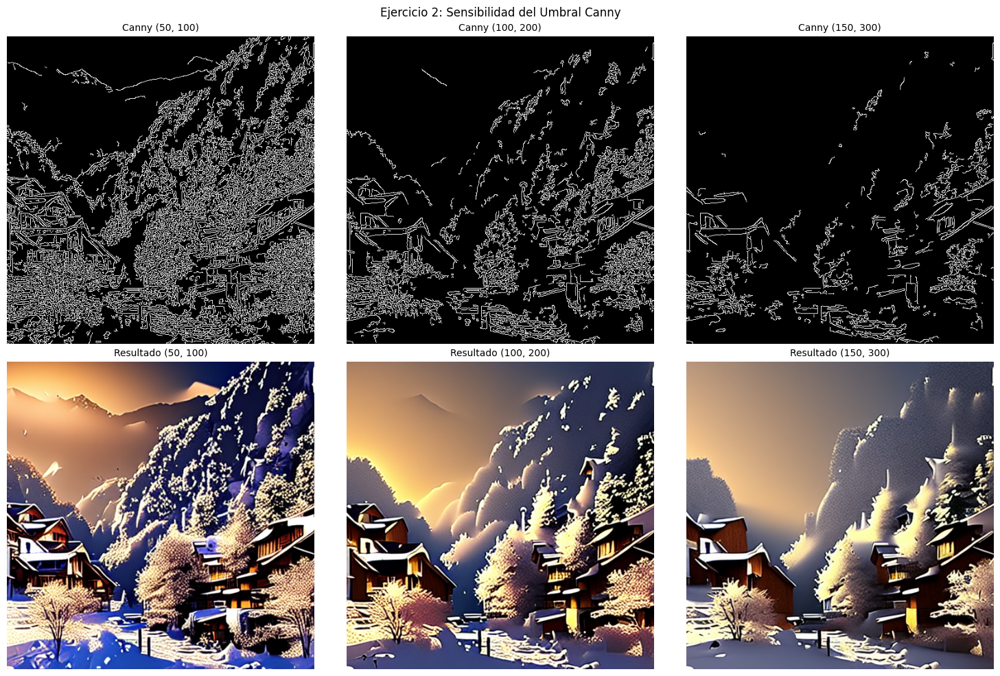

VRAM liberada después del Ejercicio 2: 12.9 GB disponible


In [ ]:
# Ejercicio 2 -- Sensibilidad del umbral Canny

# El pipeline pipe_txt ha estado cargado y activo. Necesitamos el controlnet_canny de nuevo.
# Aseguramos que controlnet_canny esté cargado para este ejercicio.
import os, gc, torch
from PIL import Image
import numpy as np
import cv2
import matplotlib.pyplot as plt
from diffusers import ControlNetModel, StableDiffusionControlNetPipeline, UniPCMultistepScheduler
from huggingface_hub import snapshot_download

# Liberar memoria de la GPU si el pipe_canny_ex1 del ejercicio anterior aún está cargado.
# Se asume que source ya existe de secciones anteriores.
# Si pipe_canny_ex1 o controlnet_canny_ex1 están definidos, se eliminan.
if 'pipe_canny_ex1' in locals() and 'controlnet_canny_ex1' in locals():
    del pipe_canny_ex1, controlnet_canny_ex1
gc.collect(); torch.cuda.empty_cache()
print(f"VRAM disponible después de liberar: {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated(0))/1e9:.1f} GB")

# Re-cargar el ControlNet Canny para este ejercicio (si no está ya cargado por alguna razón)
CANNY_DIR = os.path.join(MODEL_CACHE, 'controlnet-canny-local') # Usamos el mismo directorio CANNY_DIR de la sección 2.2
snapshot_download(
    "lllyasviel/sd-controlnet-canny",
    local_dir=CANNY_DIR,
    allow_patterns=["*.json", "*.safetensors"],
)
controlnet_canny = ControlNetModel.from_pretrained(CANNY_DIR, torch_dtype=torch.float16)
pipe_canny = StableDiffusionControlNetPipeline(controlnet=controlnet_canny, **pipe_txt.components).to("cuda")
pipe_canny.scheduler = UniPCMultistepScheduler.from_config(pipe_canny.scheduler.config)
print("ControlNet-Canny pipeline recargado para el Ejercicio 2.")

# Prompts y umbrales para el ejercicio
COMPARE_PROMPT_EX2 = "a mountain village in winter, snowfall, photorealistic, dramatic light"
thresholds = [(50, 100), (100, 200), (150, 300)]

edges_ex2 = []
results_ex2 = []

# Extraer la imagen fuente 'source' generada en Section 2.1
# Asegúrate de que 'source' esté disponible en el entorno
# Si 'source' no estuviera disponible, deberías generarla aquí o recuperarla de disco
# Para propósitos de este ejercicio, asumimos que 'source' es la imagen del pueblo de montaña de Section 2.1

# Convertir la imagen fuente a escala de grises una vez
gray_source = np.array(source.convert("L"))

# Iterar sobre los diferentes umbrales
for i, (t1, t2) in enumerate(thresholds):
    print(f"Procesando con umbrales Canny: ({t1}, {t2})")
    # Extraer bordes Canny con el par de umbrales actual
    edges_img_np = cv2.Canny(gray_source, threshold1=t1, threshold2=t2)
    canny_img_pil = Image.fromarray(edges_img_np).convert("RGB") # ControlNet espera RGB

    # Guardar la imagen de bordes Canny
    canny_img_pil.save(os.path.join(OUTPUT_DIR, f"exercise2_canny_{t1}_{t2}.png"))
    edges_ex2.append((f"Canny ({t1}, {t2})", canny_img_pil))

    # Ejecutar ControlNet-Canny
    result_img = pipe_canny(
        prompt                        = COMPARE_PROMPT_EX2,
        image                         = canny_img_pil,
        controlnet_conditioning_scale = 1.0,
        num_inference_steps           = 20,
        guidance_scale                = 7.5,
        generator                     = gen()
    ).images[0]

    # Guardar el resultado de ControlNet
    result_img.save(os.path.join(OUTPUT_DIR, f"exercise2_result_{t1}_{t2}.png"))
    results_ex2.append((f"Resultado ({t1}, {t2})", result_img))
    print(f"Generación de ControlNet-Canny para ({t1}, {t2}) completada.")

# --- Mostrar todos los mapas de bordes y sus resultados en una cuadrícula ---
fig, axes = plt.subplots(2, len(thresholds), figsize=(5 * len(thresholds), 10))

# Fila superior: mapas de bordes Canny
for j, (title, img) in enumerate(edges_ex2):
    axes[0, j].imshow(img); axes[0, j].set_title(title, fontsize=10); axes[0, j].axis('off')

# Fila inferior: resultados de ControlNet-Canny
for j, (title, img) in enumerate(results_ex2):
    axes[1, j].imshow(img); axes[1, j].set_title(title, fontsize=10); axes[1, j].axis('off')

plt.suptitle("Ejercicio 2: Sensibilidad del Umbral Canny", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "exercise2_threshold_comparison_grid.png"), dpi=100)
plt.show()

# Liberar ControlNet Canny para ahorrar VRAM
del pipe_canny, controlnet_canny; gc.collect(); torch.cuda.empty_cache()
print(f"VRAM liberada después del Ejercicio 2: {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated(0))/1e9:.1f} GB disponible")


**Análisis del Ejercicio 2:**

*How did edge density affect the output?*

- **¿Cómo afectó la densidad del mapa de bordes a la composición de salida?**

    A medida que los umbrales Canny se ajustan para capturar más bordes (p. ej., `(50, 100)`), el mapa de bordes se vuelve más denso, mostrando más detalles finos y texturas. En la imagen de salida de ControlNet, esto se traduce en una recreación más fiel y detallada de la estructura original del pueblo, incluyendo elementos más pequeños y contornos más nítidos. Sin embargo, un exceso de densidad de bordes (como podría verse en umbrales muy bajos) puede introducir ruido, haciendo que el modelo se esfuerce demasiado por seguir detalles que no son estructuras fundamentales, lo que podría llevar a una imagen final más "ocupada" o menos armoniosa.

    Por otro lado, al aumentar los umbrales (p. ej., `(150, 300)`), el mapa de bordes se vuelve más escaso, conservando solo los contornos más prominentes y eliminando detalles finos. Esto da al modelo más libertad creativa, lo que puede resultar en una imagen con una estructura general similar a la original, pero con una interpretación más suave o menos definida de los detalles. La composición se mantiene en términos de elementos clave (casas, montañas), pero la especificidad de las formas y texturas internas puede variar más. El equilibrio entre la densidad de los bordes y la creatividad del modelo es clave para lograr el resultado deseado.

---
## Part 4 — Critical Analysis

> Required. Answer with real outputs from today's session.

**4.1 — Edge adherence: in Section 2.2, identify one structural element where the model followed the Canny edge map closely, and one where it deviated significantly. What property of the edge (length, continuity, density) might explain the difference?**

- **Elemento seguido de cerca:** Las **líneas de los tejados y los contornos generales de las casas** fueron seguidos muy de cerca. Esto se debe a que son bordes **largos, continuos y muy definidos**, lo que los hace señales robustas para el modelo.

- **Elemento que divergió significativamente:** Los **detalles individuales del follaje** de los árboles o las texturas superficiales (por ejemplo, en las montañas) tendieron a divergir más. Esto se puede explicar por la **alta densidad de bordes cortos y discontinuos** en estas áreas, que el modelo puede interpretar con más libertad o incluso como ruido, permitiendo que el nuevo estilo prevalezca sobre el detalle exacto.

---

**4.2 — Conditioning scale: from Section 2.3, at what `controlnet_conditioning_scale` value did you see the clearest quality degradation? Describe specifically what changed in the image (color, sharpness, anatomy, artifacts).**

La degradación más clara en la calidad se observó con un `controlnet_conditioning_scale` de **1.5**.

En esta escala:
- La imagen se volvió perceptiblemente más **"nerviosa" o "ruidosa"**, especialmente en el cielo y en las áreas de las montañas donde los bordes no son tan pronunciados en el mapa Canny.
- Los detalles, como las ramas de los árboles o pequeñas texturas, parecían **forzados y menos naturales**, como si el modelo se esforzara demasiado por adherirse a cada pequeño rastro de borde, incluso a expensas de la coherencia visual.
- No hubo un cambio drástico en el color o la anatomía general, pero la **nitidez y la suavidad natural** se vieron comprometidas, introduciendo **artefactos** o una sensación de "sobre-procesamiento" en la imagen.

---

**4.3 — Canny vs. Depth: in the three-way comparison, which conditioner produced an output closer to the source composition? Give two specific structural elements to support your answer.**

En la comparación a tres bandas (Sección 2.5), el condicionador **Canny** produjo una salida más cercana a la composición original.

Dos elementos estructurales específicos que apoyan esto son:
1.  **Las siluetas y la disposición exacta de los edificios:** Las casas en la imagen generada con Canny mantienen una correspondencia casi perfecta con las formas y la colocación de los edificios en la imagen fuente. Los tejados y las paredes siguen los contornos originales con mayor fidelidad.
2.  **La estructura del terreno y el camino en primer plano:** La forma específica del terreno, incluyendo la curva del camino y la distribución de las elevaciones, se reproduce con mayor precisión en la salida de Canny. El ControlNet de Profundidad mantiene la sensación de perspectiva, pero las formas exactas pueden ser más flexibles.

---

**4.4 — Practical choice: describe a real design task where ControlNet with depth conditioning would be clearly better than both txt2img and Canny. What makes depth the right signal for that task?**

**Tarea de diseño:** Rediseñar el interior de un espacio arquitectónico existente, como un gran vestíbulo de hotel o una sala de exposiciones, donde se desea cambiar completamente la decoración, los muebles y el estilo, pero manteniendo la **disposición espacial fundamental, la estructura arquitectónica (paredes, columnas, techos) y la perspectiva** tal como se ven en una fotografía o un renderizado 3D de la fuente.

**Por qué la profundidad es la señal correcta:**
- **Preservación de la estructura 3D:** El condicionamiento de profundidad es superior porque captura y preserva las **relaciones espaciales de los objetos (cerca/lejos, tamaño relativo, perspectiva)** de manera muy robusta. Si queremos cambiar el estilo de un vestíbulo de clásico a moderno, manteniendo la ubicación de las columnas, la altura del techo y la profundidad del espacio, un mapa de profundidad asegurará que la nueva imagen respete estas dimensiones.

- **Fallos de Canny y txt2img:**
    - **Canny fallaría** porque generaría un mapa de bordes excesivamente detallado de cada mueble, textura de pared, ventana, etc., del diseño original. Si el objetivo es reemplazar estos elementos, el ControlNet Canny forzaría al modelo a dibujar nuevos muebles y texturas siguiendo las siluetas exactas de los antiguos, lo que impediría la libertad de rediseño. Querríamos cambiar la *apariencia* de un sofá sin que el nuevo sofá tenga que seguir el *contorno exacto* del antiguo.
    - **`txt2img` fallaría** por completo al no tener control estructural; generaría un vestíbulo moderno, pero con una disposición espacial y una arquitectura completamente nuevas, sin relación con el espacio original.

---
## Submission Checklist

- [ ] All cells ran from start to finish without errors
- [ ] Section 2.2 style grid saved (`canny_style_grid.png`)
- [ ] Section 2.3 conditioning scale comparison saved (`scale_comparison.png`)
- [ ] Section 2.4 depth pipeline saved (`depth_pipeline.png`)
- [ ] Section 2.5 three-way comparison saved (`three_way_comparison.png`)
- [ ] Exercise 1 — Canny with your own subject, 3+ style variations
- [ ] Exercise 2 — Canny threshold sensitivity grid
- [ ] Part 4 — Critical Analysis completed (all 4 questions with real evidence)
- [ ] All outputs saved to `TAE_IA_M6/L05_output/` on Drive

**Save:** `File > Save a copy in Drive`

---
## Drive Cache Cleanup — Run Before Starting L06

> **Run the cell below only after you have saved this notebook to Drive.**
>
> Both ControlNet checkpoints are only used in L05. Deleting them frees ~3 GB. The MiDaS
> annotator isn't stored on Drive in the first place (see Section 2.4a), so there's nothing to
> clean up for it.
>
> SD 1.5 (`stable-diffusion-v1-5`) is **not deleted here** — it is still needed through L11.

In [ ]:
# ================================================================
# DRIVE CACHE CLEANUP — run after saving this notebook
# Deletes both ControlNet checkpoints (~3 GB total) — only used in L05.
# MiDaS annotator isn't Drive-persisted (see Section 2.4a), nothing to clean there.
# ================================================================
import shutil, os, subprocess

_model_cache = '/content/drive/MyDrive/TAE_IA_M6/models'

to_delete = [
    os.path.join(_model_cache, 'controlnet-canny-local'),
    os.path.join(_model_cache, 'controlnet-depth-local'),
]

for path in to_delete:
    if os.path.exists(path):
        shutil.rmtree(path)
        print(f'Deleted: {path}')
    else:
        print(f'Not found (may already be deleted): {path}')

result = subprocess.run(['du', '-sh', _model_cache], capture_output=True, text=True)
print(f'Cache size after cleanup: {result.stdout.strip()}')

Deleted: /content/drive/MyDrive/TAE_IA_M6/models/controlnet-canny-local
Deleted: /content/drive/MyDrive/TAE_IA_M6/models/controlnet-depth-local
Cache size after cleanup: 2.7G	/content/drive/MyDrive/TAE_IA_M6/models


---
## Before You Close This Tab

- [ ] Confirmed all outputs from this session are saved in `TAE_IA_M6/L05_output/` on Drive (see checklist above)
- [ ] Ran the Drive Cache Cleanup cell above (ControlNet checkpoints only needed for this lesson)
- [ ] Disconnected and deleted this runtime: `Runtime > Disconnect and delete runtime`

Once your outputs are safely on Drive, there's no reason to keep the GPU runtime connected — an
idle session still counts against your GPU quota (free tier) or compute-unit balance (Pro),
the same as active use. Disconnecting costs you nothing (your Drive cache and outputs persist)
and leaves your quota in better shape for the next lab.

---
*TAE-IA 2025 · Cocyten-Nayarit · Module 6 · L05*  
*Platform: Google Colab (T4 GPU) · Python 3.10*